# Trial 1_Pulse only_XGBoost for classification

In [17]:
import os
import pandas as pd

list1 = []
for file in os.listdir("/Chrome Downloads/temp/"):
    if file.endswith("xlsx") or file.endswith("xls"):
        list1.append(file)

df = pd.DataFrame()        
for i in list1:
    excel_path = os.path.join("/Chrome Downloads/temp/",i)
    df_current = pd.read_excel(excel_path)
    df = df.append(df_current, ignore_index=True)

df.to_excel("Dataset_Changhao_20210922.xlsx", index=False)

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBRegressor
from xgboost import plot_importance
from matplotlib import pyplot as plt

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

## Load data

In [11]:
df = pd.read_excel('Dataset_Changhao_20210922.xlsx')
df.columns
df.sample(frac=1)

,Pulse Number,Start Time,End Time,Systolic Time From Start,Tidal Wave Time From Systolic,Dicrotic Time From Tidal Wave,Tail Wave Time From Dicrotic,End Time From Tail Wave,Systolic Peak Amplitude,Tidal Wave Peak Ampltiude,...,Gaussian Systolic Time From Start,Gaussian Tidal Wave Time From Systolic,Gaussian Dicrotic Time From Tidal Wave,Gaussian Tail Wave Time From Dicrotic,Gaussian End Time From Tail Wave,Gaussian Systolic Peak Amplitude,Gaussian Tidal Wave Peak Ampltiude,Gaussian Dicrotic Peak Amplitude,Gaussian Tail Wave Peak Ampltitude,Y
232,254,198.036891,198.986899,0.118751,0.118751,0.178127,0.237502,0.296878,5.298040,4.023762,...,0.118751,0.118751,0.178127,0.267190,0.267190,4.994740,3.195576,3.051573,1.377438,0
1536,456,341.161593,341.992850,0.148439,0.089063,0.178127,0.207814,0.207814,1.010652,0.795110,...,0.148439,0.089063,0.148439,0.207814,0.237502,1.003268,0.310610,0.650295,0.223776,0
2592,187,146.227700,147.148400,0.118800,0.118800,0.148500,0.267300,0.267300,1.467501,1.246994,...,0.118800,0.118800,0.148500,0.267300,0.267300,1.393855,0.967986,0.700141,0.235481,1
551,91,69.544800,70.376100,0.118800,0.118700,0.178200,0.237500,0.178100,0.994295,0.598726,...,0.118800,0.118700,0.148500,0.267200,0.178100,0.986345,0.451041,0.413259,0.129607,0
2180,261,191.625700,192.338148,0.118741,0.118741,0.178112,0.237483,0.059371,3.253378,2.034466,...,0.118741,0.118741,0.178112,0.178112,0.118741,3.084257,1.726216,1.125970,0.137472,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,34,24.564400,25.306600,0.118700,0.118800,0.148400,0.207900,0.148400,0.991462,0.560805,...,0.118700,0.118800,0.148400,0.237600,0.118700,0.940748,0.497000,0.358047,0.080227,0
1127,708,549.985312,550.786882,0.118751,0.118751,0.148439,0.296878,0.118751,2.276361,1.385260,...,0.118751,0.089063,0.178127,0.296878,0.118751,2.156215,1.079335,1.042648,0.249477,0
1097,678,526.294478,527.006984,0.118751,0.118751,0.148439,0.237502,0.089063,2.328434,1.230607,...,0.118751,0.089063,0.178127,0.237502,0.089063,2.207683,1.092366,1.005895,0.147340,0
620,165,127.439392,128.240962,0.118751,0.089063,0.178127,0.326565,0.089063,1.796398,1.066737,...,0.118751,0.089063,0.178127,0.267190,0.148439,1.770966,0.644745,0.693634,0.102791,0


In [12]:
y = df['Y'].to_numpy() # load y_train (y) in numpy form
X_df = df.drop(['Pulse Number', 'Start Time', 'End Time','Unnamed: 12','Y'], axis = 1)
X = X_df.to_numpy() # load X_train (X) in numpy form, and delete Pulse Number, Start and End Time & Y column
print(X.shape, y.shape)

(3264, 18) (3264,)


## Linear Regression with Ridge regularization: cross validation

In [15]:
scores = np.array([])
scale = np.arange(39000, 41000, 500)
max = 0
for i in scale:
    clf = Ridge(alpha = i)

    k_fold = KFold(n_splits = 10)
    score = np.mean([roc_auc_score(y[test], clf.fit(X[train], y[train]).predict(X[test])) for train, test in k_fold.split(X)])
    if score > max:
        max = score
        alpha = i
    scores = np.append(scores, score)

print("best alpha = %.4f, auc = %.8f" % (alpha, max)) # 0.645503 for mid, 0.64523 for no mid
plt.plot(scale, scores)

ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

In [16]:
clf = Ridge(alpha = alpha)
clf.fit(X, y)
y_predict = clf.predict(X)
print(roc_auc_score(y, y_predict))

NameError: name 'alpha' is not defined

## XGBoost

In [20]:
def XGBoost(X, y):
    params = {
                       # 构建树的深度，越大越容易过拟合
                # 学习率 0.009
        'verbosity': 3,                # 设置成0则没有运行信息输出 Valid values are 0 (silent) - 3 (debug).
        'objective': 'reg:squarederror',
        'booster': 'gbtree',
        'n_jobs': 8,                   # cpu 线程数
        'gamma': 0.1,                  # 用于控制是否后剪枝的参数,越大越保守，一般0.1、0.2这样子
        'min_child_weight': 3,
        'subsample': 0.7,              # 随机采样训练样本
        'colsample_bytree': 0.7,       # 生成树时进行的列采样
                       # 控制模型复杂度的权重值的L2正则化项参数，参数越大，模型越不容易过拟合。
        'random_state': 1024            # Random number seed
    }
    cv_params = {'n_estimators': [1000, 1200], 'learning_rate': [0.001], 'max_depth': [6, 8, 10], 'reg_lambda': [20]}
    
    model = XGBRegressor(**params)
    model.fit(X, y)
#    optimized_model = GridSearchCV(estimator=model, param_grid=cv_params, scoring="r2", cv=5, verbose=3, n_jobs=4)
#    optimized_model.fit(X, y)
#    best_score = optimized_model.best_score_
#    print("best auc score = %.8f" % best_score)
#    best_params = optimized_model.best_params_
#    print("best param is")
#    print(best_params)
    
#    return optimized_model.best_estimator_
    return model

In [21]:
clf = XGBoost(X, y) 

[14:26:14] DEBUG: ..\src\gbm\gbtree.cc:154: Using tree method: 2
[14:26:14] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 82 extra nodes, 2 pruned nodes, max_depth=6
[14:26:14] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 72 extra nodes, 2 pruned nodes, max_depth=6
[14:26:14] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 72 extra nodes, 12 pruned nodes, max_depth=6
[14:26:14] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 60 extra nodes, 10 pruned nodes, max_depth=6
[14:26:14] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 58 extra nodes, 16 pruned nodes, max_depth=6
[14:26:14] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 66 extra nodes, 16 pruned nodes, max_depth=6
[14:26:14] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 74 extra nodes, 12 pruned nodes, max_depth=6
[14:26:14] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 58 extra nodes, 36 pruned nodes, max_depth=6
[14:26:14] INFO: ..\src\t

[14:26:15] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 6 extra nodes, 54 pruned nodes, max_depth=3
[14:26:15] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 10 extra nodes, 54 pruned nodes, max_depth=5
[14:26:15] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 0 extra nodes, 62 pruned nodes, max_depth=0
[14:26:15] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 0 extra nodes, 84 pruned nodes, max_depth=0
[14:26:15] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 10 extra nodes, 54 pruned nodes, max_depth=5
[14:26:15] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 0 extra nodes, 44 pruned nodes, max_depth=0
[14:26:15] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 16 extra nodes, 44 pruned nodes, max_depth=6
[14:26:15] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 0 extra nodes, 26 pruned nodes, max_depth=0
[14:26:15] INFO: ..\src\tree\updater_prune.cc:101: tree pruning end, 0 extra nodes, 56 pruned

In [22]:
y_predict.shape

(12507,)

In [23]:
np.argwhere(np.isnan(y))

array([], shape=(0, 1), dtype=int64)

MSE: 0.0003


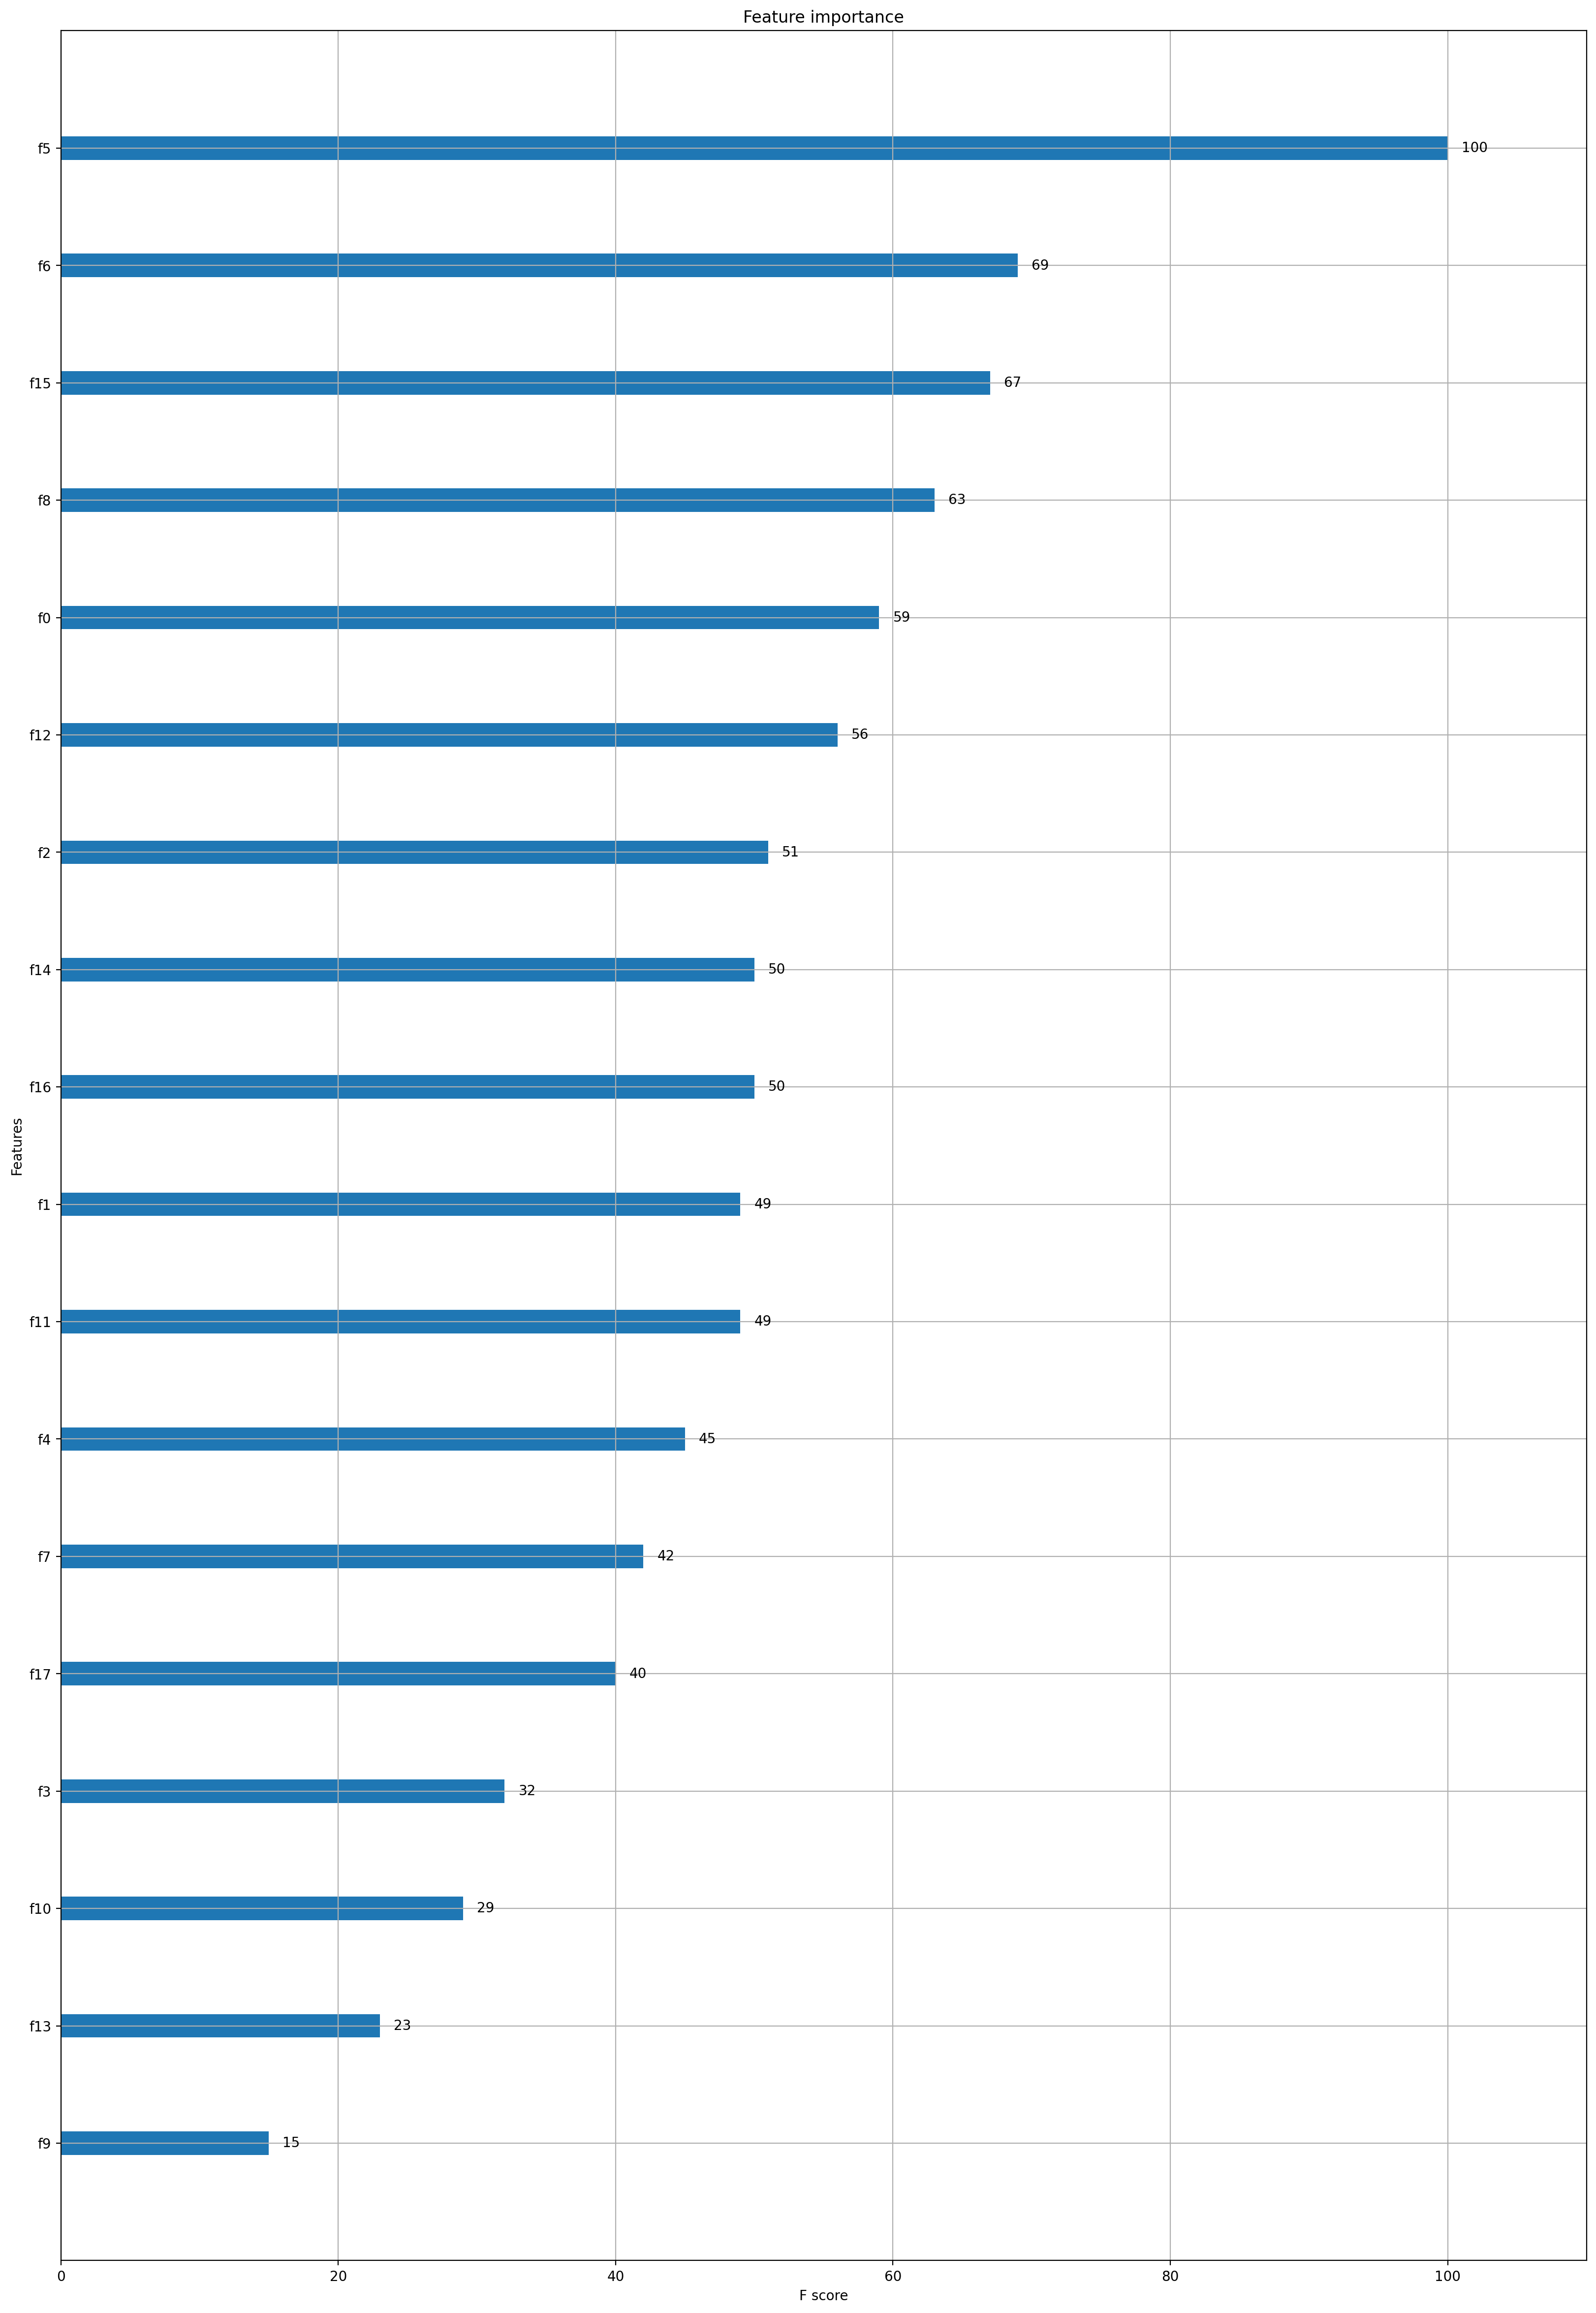

<Figure size 4000x6000 with 0 Axes>

In [26]:
y_predict = clf.predict(X)
y_predict = np.where(abs(y_predict) <= 0.5, 0, y_predict)
y_predict = np.where(abs(y_predict - 1) <= 0.5, 1, y_predict)
# y_predict = np.where(abs(y_predict - 2) <= 0.5, 2, y_predict)
# y_predict = np.where(abs(y_predict) >= 2.5, 3, y_predict)
# evaluate the splited test set
mse = mean_squared_error(y, y_predict)
print("MSE: %.4f" % mse)

# roc = roc_auc_score(y, y_predict)
# print("ROC: %.8f" % roc)   # 0.73540287

# plot importance
plot_importance(clf, max_num_features = X.shape[1])
plt.rcParams["figure.figsize"] = (20,30)
plt.rcParams["figure.dpi"] = 200
plt.show()

fig = plt.gcf()
fig.savefig('./feature_importance.png')

## Validate test data: not started yet

In [8]:
df2 = pd.read_excel('Real time data.xlsx')
df2.columns

Index(['id', 'last_price', 'mid', 'opened_position_qty ',
       'closed_position_qty', 'transacted_qty', 'd_open_interest', 'bid1',
       'bid2', 'bid3', 'bid4', 'bid5', 'ask1', 'ask2', 'ask3', 'ask4', 'ask5',
       'bid1vol', 'bid2vol', 'bid3vol', 'bid4vol', 'bid5vol', 'ask1vol',
       'ask2vol', 'ask3vol', 'ask4vol', 'ask5vol'],
      dtype='object')

In [10]:
X_df2 = df.drop(['Pulse Number', 'Start Time', 'End Time','Unnamed: 12','Y'], axis = 1)
X = X_df2.to_numpy()
y_predict = clf.predict(X)


In [11]:
id = df2['id'].to_numpy()
submission = np.c_[id, y_predict]
df_sub = pd.DataFrame(submission, columns=['id', 'Predicted'])
df_sub.loc[df_sub['Predicted'] > 1, ['Predicted']] = 1
df_sub.loc[df_sub['Predicted'] < 0, ['Predicted']] = 0
df_sub['id'] = df_sub['id'].astype(np.int32)
out_path = './submission_xgb_lr0_003_iter_1500_depth_25_lambda_8.csv'
df_sub.to_csv(out_path, index=False)